In [37]:
# Tyson (1991) six-ODE model solved with Radau solver for stiff systems
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# === Parameters: Table 2 values with some scaling to reduce stiffness ===
p = {
    "k1_aa_over_CT": 0.015,  # cyclin synthesis (min-1)
    "k2": 0.0,               # cyclin degradation
    "k3_CT": 200.0,          # k3·[CT]
    "k4": 180.0,             # activation rate (min-1)
    "k4prime": 0.018,        # baseline activation (min-1)
    "k5_minusP": 0.0,
    "k6": 1.0,               # inactivation rate (min-1)
    "k7": 0.6,               # YP decay (min-1)
    "k8_minusP": 100.0,      # reduced from 1e3 to improve stability
    "k9": 50.0,              # reduced from 1e2 to improve stability
    "CT": 1.0
}

In [38]:
def F_M(M, p):  # MPF activation function
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def f(t, state):
    # Ensure non-negative values
    C2, CP, pM, M, Y, YP = state
    
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    # Calculate rates with improved numerical stability
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

In [39]:
# === Initial conditions ===
CT = p["CT"]
y = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
t_span = (0, 100)
sol = solve_ivp(f, t_span, y, method='BDF', 
                rtol=1e-6, atol=1e-8,  # stricter error tolerances
                max_step=0.1)          # limit maximum step size

if not sol.success:
    print(f"Integration failed: {sol.message}")

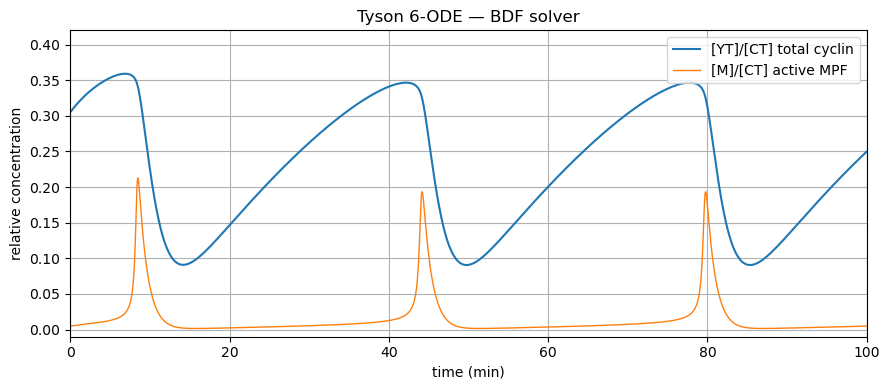

In [40]:
# === Observables ===
t = sol.t
y_sol = sol.y
C2, CP, pM, M, Y, YP = y_sol

YT = Y + YP + pM + M
M_rel = M / CT
YT_rel = YT / CT

# === Plot (should reproduce Tyson Fig. 3a) ===
plt.figure(figsize=(9,4))
plt.plot(t, YT_rel, lw=1.5, label='[YT]/[CT] total cyclin')
plt.plot(t, M_rel, lw=1.0, label='[M]/[CT] active MPF')
plt.xlim(0,100)
plt.ylim(-0.01,0.42)
plt.xlabel('time (min)')
plt.ylabel('relative concentration')
plt.title('Tyson 6-ODE — BDF solver')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

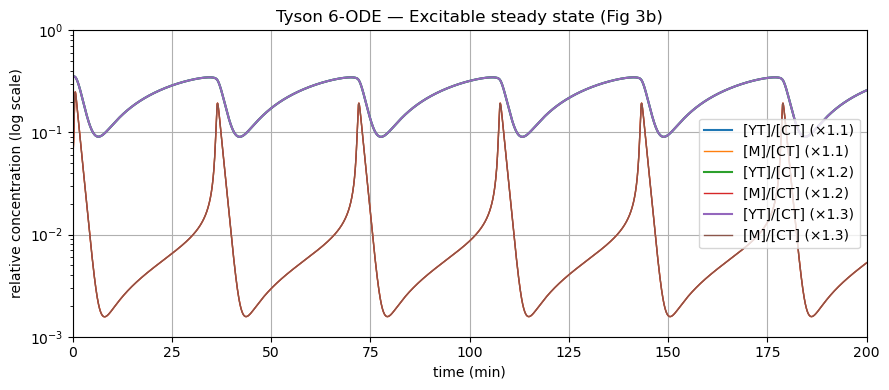

In [43]:
# === Figure 3b: Excitable steady state ===
# Create new parameter set with k6 = 2
p_excitable = p.copy()
p_excitable["k6"] = 2.0

# Function to simulate with perturbation at specific time
def simulate_with_perturbation(p, t_perturb, m_multiplier, tmax=200):
    y0 = np.array([0.9, 0.05, 0.0, 0.05, 0.3, 0.0])
    t_eval = np.linspace(0, tmax, int(tmax*100))  # Dense output for smooth curves
    
    def f_with_perturbation(t, state):
        if abs(t - t_perturb) < 0.01:  # Apply perturbation at t_perturb
            state[3] = state[3] * m_multiplier  # Multiply M by the scaling factor
        return f(t, state)
    
    sol = solve_ivp(f_with_perturbation, (0, tmax), y0, 
                    t_eval=t_eval, method='BDF',
                    rtol=1e-6, atol=1e-8)
    return sol

# Run three simulations with different perturbation multipliers
perturbations = [(20, 1.1), (40, 1.2), (60, 1.3)]  # (time, M multiplier)
sols_excitable = []

for t_pert, m_mult in perturbations:
    sol = simulate_with_perturbation(p_excitable, t_pert, m_mult)
    sols_excitable.append(sol)

# Plot excitable steady state (Fig 3b)
plt.figure(figsize=(9,4))
for i, sol in enumerate(sols_excitable):
    t = sol.t
    y_sol = sol.y
    M = y_sol[3]
    Y, YP, pM = y_sol[4], y_sol[5], y_sol[2]
    YT = Y + YP + pM + M
    
    M_rel = M / CT
    YT_rel = YT / CT
    
    mult = perturbations[i][1]
    plt.semilogy(t, YT_rel, lw=1.5, label=f'[YT]/[CT] (×{mult})')
    plt.semilogy(t, M_rel, lw=1.0, label=f'[M]/[CT] (×{mult})')

plt.xlim(0,200)
plt.ylim(1e-3,1)
plt.xlabel('time (min)')
plt.ylabel('relative concentration (log scale)')
plt.title('Tyson 6-ODE — Excitable steady state (Fig 3b)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

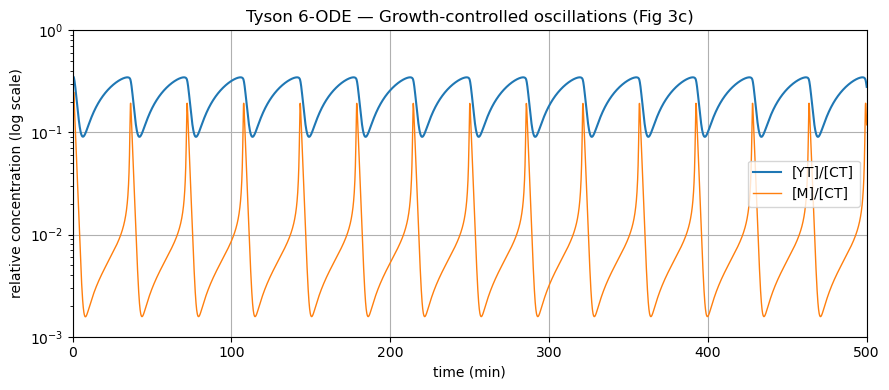

In [42]:
# === Figure 3c: Growth-controlled oscillations ===
# Function for time-dependent k6
def f_growth_controlled(t, state):
    # Mass doubling time
    Td = 116  # minutes
    
    # Calculate current k6 based on cell cycle phase
    # k6 varies between 1 and 2, with sharp transitions
    cycle_phase = (t % Td) / Td
    
    if state[3] > 0.1:  # If MPF is high, increase k6 to trigger division
        k6 = 2.0
    else:
        k6 = 1.0 + cycle_phase  # Gradually increase during growth
    
    # Update parameter
    p_growth = p_excitable.copy()
    p_growth["k6"] = k6
    
    return f(t, state)

# Simulate growth-controlled system
t_span = (0, 500)  # Longer simulation to see multiple cycles
y0 = np.array([0.9, 0.05, 0.0, 0.05, 0.3, 0.0])
t_eval = np.linspace(0, 500, 5000)  # Dense output for smooth curves

sol_growth = solve_ivp(f_growth_controlled, t_span, y0,
                      t_eval=t_eval, method='BDF',
                      rtol=1e-6, atol=1e-8)

# Plot growth-controlled oscillations (Fig 3c)
t = sol_growth.t
y_sol = sol_growth.y
M = y_sol[3]
Y, YP, pM = y_sol[4], y_sol[5], y_sol[2]
YT = Y + YP + pM + M

M_rel = M / CT
YT_rel = YT / CT

plt.figure(figsize=(9,4))
plt.semilogy(t, YT_rel, lw=1.5, label='[YT]/[CT]')
plt.semilogy(t, M_rel, lw=1.0, label='[M]/[CT]')
plt.xlim(0,500)
plt.ylim(1e-3,1)
plt.xlabel('time (min)')
plt.ylabel('relative concentration (log scale)')
plt.title('Tyson 6-ODE — Growth-controlled oscillations (Fig 3c)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()